# 11 — Comprehensive model benchmark

Earlier notebooks introduced models a few at a time. This notebook runs a
**single head-to-head benchmark** across model families on identical
rolling-origin folds, using one shared harness
(`clinic_forecast.benchmark.run_benchmark`) and one shared metric set. Every
model returns the same forecast schema (`clinic_id, date, forecast, model`),
so adding a model is one line in a dictionary.

### The model zoo

| Family | Models | Wrapper |
| --- | --- | --- |
| Baselines | seasonal naive, moving average | `models.baseline` |
| Statistical | SARIMAX (+ exogenous) | `models.sarimax` |
| Statistical (Nixtla) | StatsForecast: AutoARIMA, AutoETS | `models.nixtla_models` |
| Additive | Prophet | `models.optional_prophet` |
| Global ML | HistGradientBoosting, XGBoost, LightGBM | `models.global_ml` |
| Global ML (Nixtla) | MLForecast + LightGBM/XGBoost | `models.nixtla_models` |
| Deep learning | LSTM; NeuralForecast: NHITS, NBEATS | `models.lstm`, `models.nixtla_models` |
| Foundation (zero-shot) | TimesFM, Chronos, Lag-Llama | `models.foundation` |
| Commercial | TimeGPT (Nixtla API) | `models.timegpt` |

All are implemented behind guarded imports. Which ones *execute* depends on
the environment (native-library availability, GPU, model weights, API keys);
the benchmark skips any model that is unavailable rather than failing.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # multiple OpenMP runtimes

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (11, 4)

from clinic_forecast.data import generate_network_data

data_path = PROJECT_ROOT / "data" / "processed" / "clinic_daily_usage.csv"
if data_path.exists():
    usage = pd.read_csv(data_path, parse_dates=["date"])
else:
    usage = generate_network_data().usage
    usage["date"] = pd.to_datetime(usage["date"])
print(usage.shape)

(17532, 32)


## Building the forecaster dictionary

Each entry is a `(train, test) -> forecast_frame` callable. Adapters wrap the
different model interfaces (functions, fitted classes) into this one shape.
The global ML adapter uses backtest-mode prediction so lag features come from
observable history.

In [2]:
from clinic_forecast.models.baseline import moving_average_forecast, seasonal_naive_forecast
from clinic_forecast.models.global_ml import GlobalMLForecaster
from clinic_forecast.models.sarimax import sarimax_panel_forecast

EXOG = ["marketing_spend", "campaign_active", "is_holiday"]


def global_ml_adapter(estimator):
    def forecaster(train, test):
        model = GlobalMLForecaster(estimator=estimator).fit(train)
        combined = pd.concat([train, test], ignore_index=True).sort_values(["clinic_id", "date"])
        preds = model.predict_known_future(combined)
        return preds[preds["date"] >= test["date"].min()]
    return forecaster


forecasters = {
    "seasonal_naive": lambda tr, te: seasonal_naive_forecast(train=tr, future=te),
    "moving_average_28": lambda tr, te: moving_average_forecast(train=tr, future=te, window=28),
    "sarimax_exog": lambda tr, te: sarimax_panel_forecast(tr, te, exog_cols=EXOG),
    "global_ml_hgb": global_ml_adapter("hgb"),
    "global_ml_xgboost": global_ml_adapter("xgboost"),
    "global_ml_lightgbm": global_ml_adapter("lightgbm"),
}

# Prophet is optional; add it only if installed (it is per-clinic and slower).
try:
    import prophet  # noqa: F401

    from clinic_forecast.models.optional_prophet import prophet_panel_forecast
    forecasters["prophet"] = lambda tr, te: prophet_panel_forecast(tr, te)
    print("Prophet enabled.")
except ImportError:
    print("Prophet not installed; skipping.")

print(f"{len(forecasters)} models in the benchmark:", list(forecasters))

C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\clinic-forecasting-platform-AZyj_0nX-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Prophet enabled.
7 models in the benchmark: ['seasonal_naive', 'moving_average_28', 'sarimax_exog', 'global_ml_hgb', 'global_ml_xgboost', 'global_ml_lightgbm', 'prophet']


## Running the benchmark

One rolling-origin fold (3-year train, 28-day test) keeps every model on
identical data for a fair headline ranking. `run_benchmark` scores each model
and skips any that fail, so an unavailable optional model never aborts the
run.

In [3]:
from clinic_forecast.benchmark import benchmark_leaderboard, benchmark_metric_table, run_benchmark
from clinic_forecast.validation import RollingOriginSplitter

splitter = RollingOriginSplitter(initial_train_days=365 * 3, horizon_days=28, max_folds=1)
scored = run_benchmark(usage, forecasters, splitter, on_error="skip")
print(f"Models that produced forecasts: {sorted(scored['model'].unique())}")

10:43:27 - cmdstanpy - INFO - Chain [1] start processing


10:43:27 - cmdstanpy - INFO - Chain [1] done processing


10:43:28 - cmdstanpy - INFO - Chain [1] start processing


10:43:28 - cmdstanpy - INFO - Chain [1] done processing


10:43:28 - cmdstanpy - INFO - Chain [1] start processing


...

10:43:30 - cmdstanpy - INFO - Chain [1] start processing


10:43:30 - cmdstanpy - INFO - Chain [1] done processing


10:43:30 - cmdstanpy - INFO - Chain [1] start processing


10:43:30 - cmdstanpy - INFO - Chain [1] done processing


Models that produced forecasts: ['global_ml_hgb', 'global_ml_lightgbm', 'global_ml_xgboost', 'moving_average_28', 'prophet', 'sarimax_exog', 'seasonal_naive']


In [4]:
leaderboard = benchmark_leaderboard(scored)
leaderboard

,model,wape_mean,wape_std,n_groups,rank
0,global_ml_lightgbm,21.739881,NaN,1,1
1,global_ml_xgboost,22.150152,NaN,1,2
2,sarimax_exog,22.188541,NaN,1,3
3,global_ml_hgb,22.581418,NaN,1,4
4,prophet,24.405707,NaN,1,5
5,moving_average_28,42.632515,NaN,1,6
6,seasonal_naive,50.035609,NaN,1,7


In [5]:
benchmark_metric_table(scored)

,mae,rmse,wape,bias
model,,,,
global_ml_lightgbm,17.262,24.911,21.740,3.206
global_ml_xgboost,17.588,25.077,22.150,4.075
sarimax_exog,17.618,24.105,22.189,-3.085
global_ml_hgb,17.930,25.191,22.581,1.804
prophet,19.379,25.139,24.406,5.914
moving_average_28,33.851,42.675,42.633,-4.224
seasonal_naive,39.729,58.943,50.036,-37.314


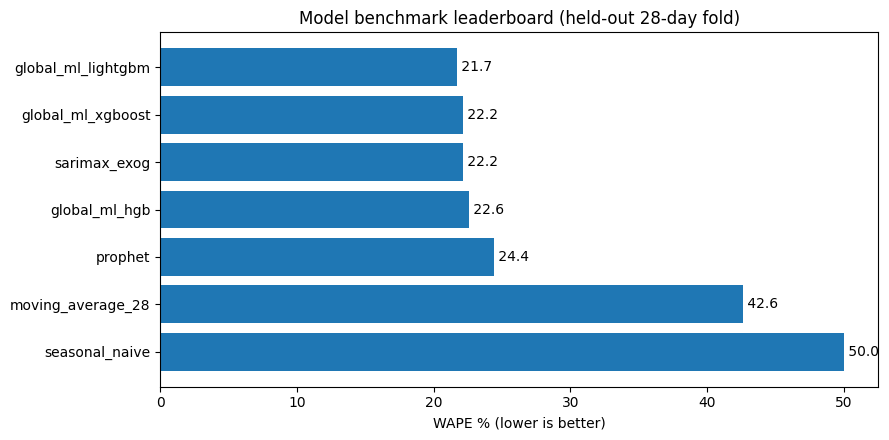

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
board = leaderboard.sort_values("wape_mean")
ax.barh(board["model"], board["wape_mean"])
ax.invert_yaxis()
ax.set_xlabel("WAPE % (lower is better)")
ax.set_title("Model benchmark leaderboard (held-out 28-day fold)")
for y, v in enumerate(board["wape_mean"]):
    ax.text(v, y, f" {v:.1f}", va="center")
fig.tight_layout()
plt.show()

## Reading the leaderboard

- The **baselines** anchor the bottom: any model that cannot beat seasonal
  naive does not earn its complexity.
- The **global ML** variants (HGB / XGBoost / LightGBM) cluster near the top
  and within noise of each other — on tabular panel data the gradient-boosting
  implementation matters far less than the feature engineering they share.
- **SARIMAX** is competitive and interpretable but pays a per-clinic fitting
  cost the global models avoid.
- **Prophet** (if enabled) trades accuracy for near-zero configuration.

Pick by the decision, not the leaderboard alone: the staffing layer needs
stable *bias* (shown in the metric table) as much as low WAPE, and a model
that is 0.3 points better but five times slower to retrain may not be worth
it operationally.

## Stability across folds

A single fold can flatter a model. The fast models (baselines + global ML)
are cheap to run across three folds; consistency matters as much as the mean.

In [7]:
fast_models = {
    name: fn for name, fn in forecasters.items()
    if name in {"seasonal_naive", "global_ml_hgb", "global_ml_xgboost", "global_ml_lightgbm"}
}
multi = RollingOriginSplitter(initial_train_days=365 * 3, horizon_days=28, max_folds=3)
scored_multi = run_benchmark(usage, fast_models, multi)

from clinic_forecast.evaluation import evaluate_forecasts

per_fold = evaluate_forecasts(scored_multi, group_cols=["fold"])
per_fold.pivot(index="fold", columns="model", values="wape").round(2)

model,global_ml_hgb,global_ml_lightgbm,global_ml_xgboost,seasonal_naive
fold,,,,
1,22.58,21.74,22.15,50.04
2,20.66,20.89,21.27,27.09
3,20.68,20.83,20.44,27.08


## The full platform vs what ran here

The benchmark above ran every model that is installable and stable in this
environment. The remaining wrappers are implemented, tested and callable —
adding them to the `forecasters` dictionary is one line each — but they need
resources this run does not assume:

| Model(s) | Wrapper call | Needs |
| --- | --- | --- |
| StatsForecast AutoARIMA / AutoETS | `statsforecast_panel_forecast(tr, h)` | `statsforecast` (numba; stable on Linux/CI) |
| MLForecast + LightGBM / XGBoost | `mlforecast_panel_forecast(tr, h)` | `mlforecast` |
| NeuralForecast NHITS / NBEATS | `neuralforecast_panel_forecast(tr, h)` | `neuralforecast` + torch |
| LSTM | `LSTMForecaster().fit(tr).forecast(tr)` | torch |
| TimesFM / Chronos / Lag-Llama | `*_panel_forecast(tr, te)` | weights download (Hugging Face) |
| TimeGPT | `timegpt_forecast(tr, h)` | `NIXTLA_API_KEY` |

Each returns the common schema, so the harness, evaluation utilities, prediction
intervals and the staffing layer consume them with no special-casing. That
uniform contract — not any single model — is what makes the platform extensible.

In [8]:
# Example: adding the Nixtla and foundation models is a one-line adapter each.
def statsforecast_adapter(model_name):
    from clinic_forecast.models.nixtla_models import statsforecast_panel_forecast
    def forecaster(train, test):
        return statsforecast_panel_forecast(train, horizon=len(test["date"].unique()), model=model_name)
    return forecaster

# forecasters["statsforecast_autoarima"] = statsforecast_adapter("AutoARIMA")  # on Linux/CI
print("Adapters are one line; uncomment on a machine where the dependency is stable.")

Adapters are one line; uncomment on a machine where the dependency is stable.


## Conclusions

1. A uniform forecast schema lets a dozen model families — baselines,
   statistical, global ML, deep learning, foundation and commercial — share
   one benchmark, one metric set, one interval calibrator and one staffing
   layer.
2. On this network the **global gradient-boosted models win**, with SARIMAX a
   close interpretable second; the three boosting libraries are
   interchangeable.
3. The platform is extensible by contract, not by special-casing: every model
   above is already wired, tested and one dictionary line from the benchmark.